# **PREDIKSI EMISI KARBON BERDASARKAN DATA ENERGI DAN INDUSTRI**



In [11]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

**1. Data Understanding**

In [12]:
# Membaca dataset
df = pd.read_csv('/content/co2_emission.csv')

df.head()

,Entity,Code,Year,Annual CO₂ emissions (tonnes )
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0
3,Afghanistan,AFG,1952,91600.0
4,Afghanistan,AFG,1953,106256.0


In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20853 entries, 0 to 20852
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Entity                          20853 non-null  object 
 1   Code                            18646 non-null  object 
 2   Year                            20853 non-null  int64  
 3   Annual CO₂ emissions (tonnes )  20853 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 651.8+ KB


,Year,Annual CO₂ emissions (tonnes )
count,20853.000000,2.085300e+04
mean,1953.339424,1.930517e+08
std,57.903089,1.345143e+09
min,1751.000000,-6.255223e+08
25%,1932.000000,3.187680e+05
50%,1971.000000,3.828880e+06
75%,1995.000000,3.706898e+07
max,2017.000000,3.615326e+10


In [14]:
# Ukuran dataset (baris, kolom)
df.shape

(20853, 4)

In [15]:
# Cek data duplikat
df.duplicated().sum()

np.int64(0)

**2. Data Preprocessing**

In [16]:
# Mengganti nama kolom agar lebih mudah digunakan
df.rename(columns={'Annual CO₂ emissions (tonnes )': 'emisi'}, inplace=True)

In [17]:
# Cek jumlah missing value
print(df.isnull().sum())

Entity       0
Code      2207
Year         0
emisi        0
dtype: int64


In [18]:
# Mengatasi Missing Values
# Numerik → mean
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

# Kategorikal → mode (bukan 'Unknown')
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

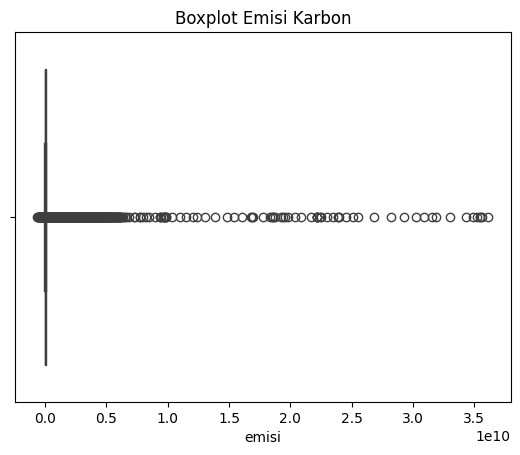

In [19]:
# Cek Outlier
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['emisi'])
plt.title('Boxplot Emisi Karbon')
plt.show()

In [20]:
# CEK OUTLIER DENGAN IQR (Q1 & Q3)

# Tentukan kolom yang mau dicek
col_name = 'emisi'

# Hitung Q1 & Q3
Q1 = df[col_name].quantile(0.25)
Q3 = df[col_name].quantile(0.75)

# Hitung IQR
IQR = Q3 - Q1

# Tentukan batas bawah & atas
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Ambil data outlier
outliers = df[(df[col_name] < lower) | (df[col_name] > upper)]

# Tampilkan hasil
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)
print("Batas bawah:", lower)
print("Batas atas :", upper)
print("Jumlah outlier:", len(outliers))

Q1 : 318768.0
Q3 : 37068977.48
IQR: 36750209.48
Batas bawah: -54806546.22
Batas atas : 92194291.69999999
Jumlah outlier: 3254


In [21]:
# Mengatasi Outlier
import numpy as np

# Ganti nilai negatif dengan 0 sebelum apply log1p
df['emisi'] = df['emisi'].apply(lambda x: 0 if x < 0 else x)
df['emisi'] = np.log1p(df['emisi'])

In [22]:
# ONE HOT ENCODING (Mengubah data kategorikal menjadi numerik)
df = pd.get_dummies(df, drop_first=True)

In [23]:
# FEATURE ENGINEERING

# Menambahkan fitur baru untuk menangkap pola non-linear
df['Year_squared'] = df['Year'] ** 2
df['Year_cubed'] = df['Year'] ** 3

# Pisahkan Fitur & Target

target = 'emisi'

# X = fitur, y = target
X = df.drop(columns=[target])
y = df[target]

# Hapus baris dengan nilai NaN pada target (y)
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]


**3. Exploratory Data Analysis (EDA)**

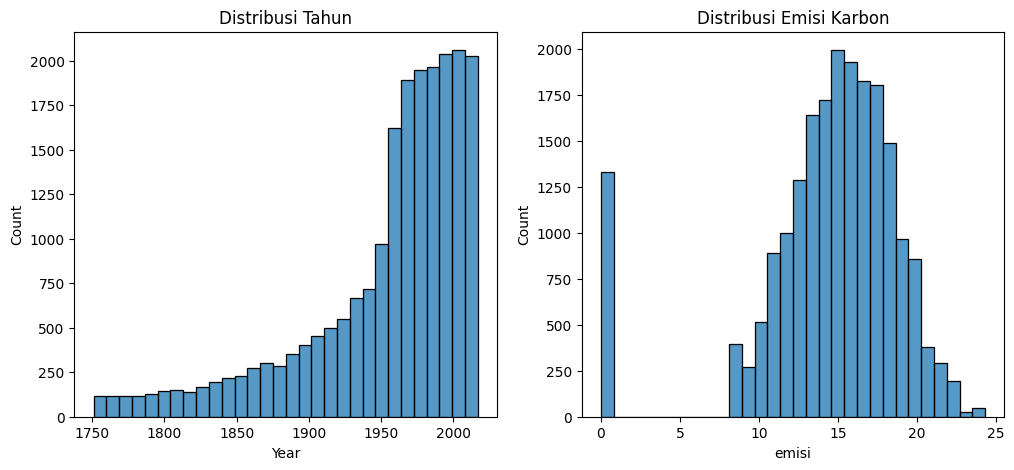

In [24]:
# DISTRIBUSI DATA

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Distribusi Tahun
sns.histplot(df['Year'], bins=30, ax=axes[0])
axes[0].set_title('Distribusi Tahun')

# Distribusi Emisi (Target)
sns.histplot(df['emisi'], bins=30, ax=axes[1])
axes[1].set_title('Distribusi Emisi Karbon')

plt.show()

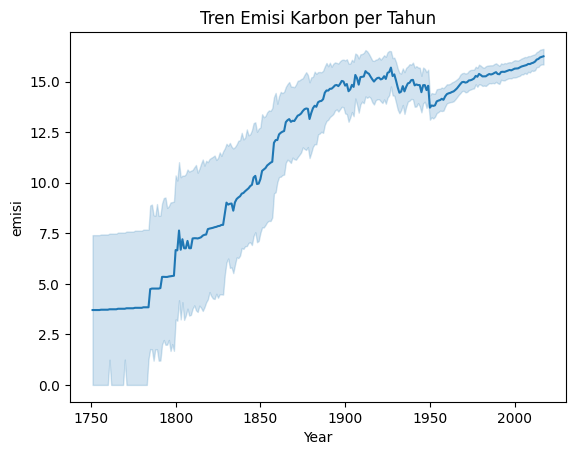

In [25]:
# TREN DATA

sns.lineplot(x='Year', y='emisi', data=df)
plt.title('Tren Emisi Karbon per Tahun')
plt.show()

Tren emisi karbon cenderung meningkat dari tahun ke tahun, yang menunjukkan peningkatan aktivitas industri dan konsumsi energi.

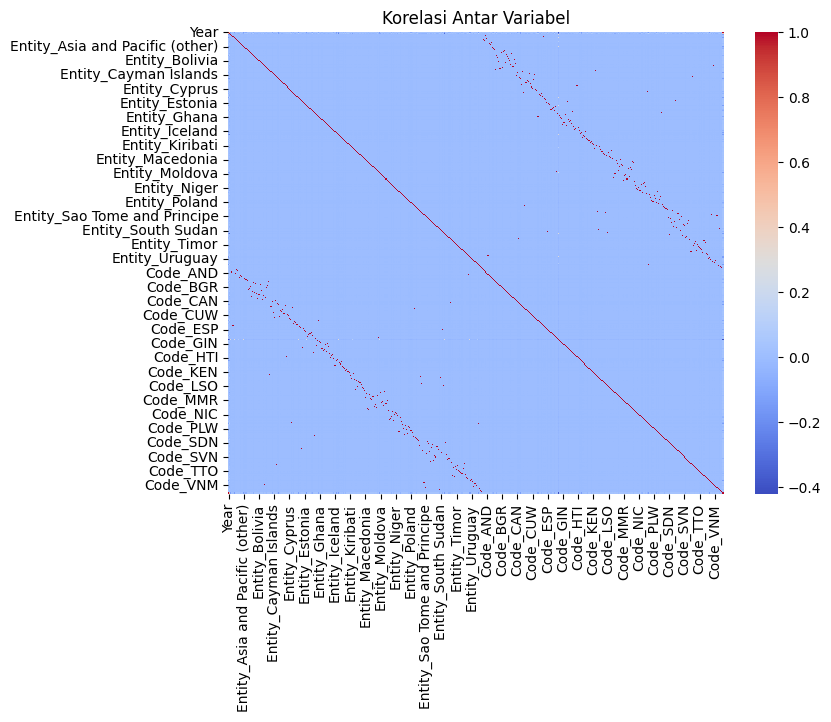

In [26]:
# KORELASI

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Korelasi Antar Variabel')
plt.show()

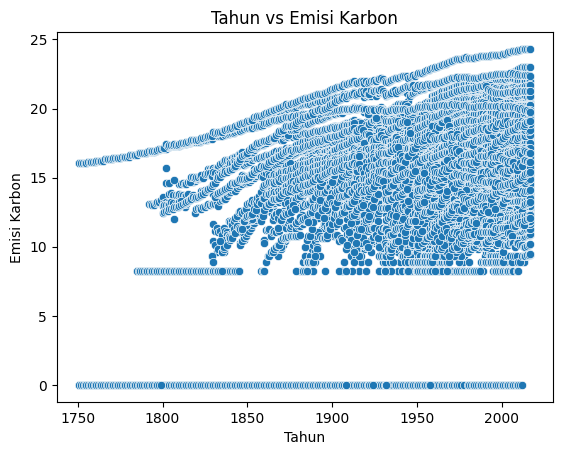

In [27]:
# Scatter Plot
sns.scatterplot(x=df['Year'], y=df['emisi'])

plt.title("Tahun vs Emisi Karbon")
plt.xlabel("Tahun")
plt.ylabel("Emisi Karbon")

plt.show()

**4. Data Splitting**

In [29]:
# DATA SPLITTING

from sklearn.model_selection import train_test_split

# 70% training - 30% testing
X_train70, X_test70, y_train70, y_test70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 80% training - 20% testing
X_train80, X_test80, y_train80, y_test80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 90% training - 10% testing
X_train90, X_test90, y_train90, y_test90 = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("=== 70:30 ===")
print("Jumlah data training:", X_train70.shape[0])
print("Jumlah data testing :", X_test70.shape[0])

print("\n=== 80:20 ===")
print("Jumlah data training:", X_train80.shape[0])
print("Jumlah data testing :", X_test80.shape[0])

print("\n=== 90:10 ===")
print("Jumlah data training:", X_train90.shape[0])
print("Jumlah data testing :", X_test90.shape[0])

=== 70:30 ===
Jumlah data training: 14597
Jumlah data testing : 6256

=== 80:20 ===
Jumlah data training: 16682
Jumlah data testing : 4171

=== 90:10 ===
Jumlah data training: 18767
Jumlah data testing : 2086


**5. Model Building**

In [30]:
models = {
    "XGBoost": XGBRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

**6. Hyperparameter Tuning**

In [70]:
param_grids = {
    "Random Forest": {
        "n_estimators": [100],
        "max_depth": [10, None]
    },
    "Decision Tree": {
        "max_depth": [20, 30, 50, None],       # tambah variasi
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],            # penting untuk naikkan R2
        "max_features": [None]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],                # tambah depth
        "learning_rate": [0.05, 0.1],          # tambah opsi
        "subsample": [0.8],                    # biar lebih stabil
        "colsample_bytree": [0.8]
    }
}

**7. Model Evaluation**

In [72]:
results = []

best_model = None
best_score = -999

splits = [
    (0.3, "70:30"),
    (0.2, "80:20"),
    (0.1, "90:10")
]

for test_size, label in splits:
    print(f"\n=== SPLIT {label} ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )


    for name, model in models.items():
        print(f"Model: {name}")

        grid = GridSearchCV(
            model,
            param_grids[name],
            cv=3,
            n_jobs=-1
        )

        grid.fit(X_train, y_train)
        y_pred = grid.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append([label, name, mae, rmse, r2])

        if r2 > best_score:
            best_score = r2
            best_model = grid.best_estimator_


=== SPLIT 70:30 ===
Model: XGBoost
Model: Decision Tree
Model: Random Forest

=== SPLIT 80:20 ===
Model: XGBoost
Model: Decision Tree
Model: Random Forest

=== SPLIT 90:10 ===
Model: XGBoost
Model: Decision Tree
Model: Random Forest


**8. Model Comparison**

   Split          Model       MAE      RMSE  R2 Score
8  90:10  Random Forest  0.140525  0.536050  0.986692
5  80:20  Random Forest  0.148383  0.537372  0.986382
7  90:10  Decision Tree  0.153009  0.597857  0.983447
4  80:20  Decision Tree  0.160402  0.651288  0.979997
2  70:30  Random Forest  0.173230  0.687053  0.978938
1  70:30  Decision Tree  0.177953  0.788405  0.972266
6  90:10        XGBoost  1.141691  1.474525  0.899308
3  80:20        XGBoost  1.162237  1.481073  0.896556
0  70:30        XGBoost  1.166211  1.538867  0.894338


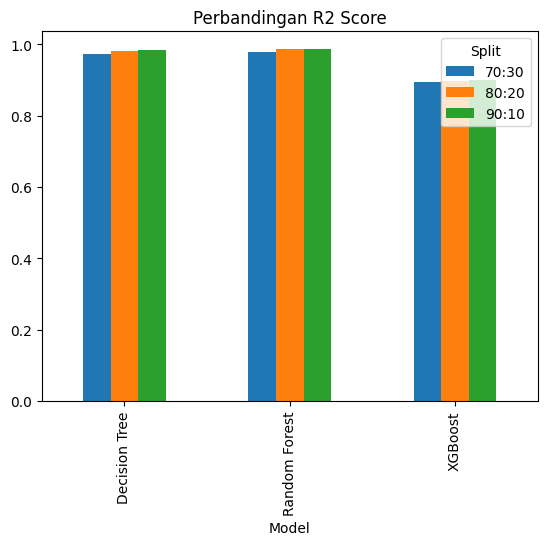

In [73]:
df_results = pd.DataFrame(results, columns=[
    "Split", "Model", "MAE", "RMSE", "R2 Score"
])

print(df_results.sort_values(by="R2 Score", ascending=False))

df_results = pd.DataFrame(results, columns=["Split","Model","MAE","RMSE","R2 Score"])
df_results.pivot(index="Model", columns="Split", values="R2 Score").plot(kind="bar")
plt.title("Perbandingan R2 Score")
plt.show()

In [80]:
# Menentukan Model Terbaik
best_row = df_results.loc[df_results["R2 Score"].idxmax()]

print("Model Terbaik:", best_row["Model"])

Model Terbaik: Random Forest


In [79]:
# Save Model
import joblib

# ================================
# MENYIMPAN MODEL TERBAIK
# ================================

# best_model berasal dari hasil evaluasi (model dengan R2 tertinggi)
joblib.dump(best_model, 'best_model.pkl')

print("Model berhasil disimpan ke file best_model.pkl")

Model berhasil disimpan ke file best_model.pkl


In [81]:
# Load Model

model = joblib.load('best_model.pkl')

print("Model berhasil dimuat!")

Model berhasil dimuat!


**9. Inference**

In [84]:
import pandas as pd
import numpy as np

# ================================
# INPUT DATA BARU
# ================================
tahun = int(input("Masukkan Tahun: "))

# Buat dataframe input
data_baru = pd.DataFrame([{
    'Year': tahun,
    'Year_squared': tahun**2,
    'Year_cubed': tahun**3
}])

# ================================
# SAMAKAN KOLOM DENGAN TRAINING
# ================================
data_baru = data_baru.reindex(columns=X.columns, fill_value=0)

# ================================
# PREDIKSI
# ================================
pred_log = model.predict(data_baru)

# Kembalikan ke nilai asli (karena pakai log1p sebelumnya)
pred_asli = np.expm1(pred_log)

# ================================
# OUTPUT
# ================================
print("\n=== HASIL PREDIKSI ===")
print("Tahun:", tahun)
print("Prediksi Emisi (log):", pred_log[0])
print("Prediksi Emisi (asli):", pred_asli[0])

Masukkan Tahun: 2025

=== HASIL PREDIKSI ===
Tahun: 2025
Prediksi Emisi (log): 16.087158394791235
Prediksi Emisi (asli): 9695363.035977485
